
<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/10_Lab_langevineP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Movimiento browniano

Una partícula inmersa en un líquido experimenta fricción y
fluctuaciones producidas por las colisiones moleculares.
Para una partícula libre, la ecuación de Langevin es

$$
m\frac{d^2x}{dt^2}
=
-\gamma\frac{dx}{dt}+\xi(t),
$$

donde $m$ es la masa, $\gamma$ es el coeficiente de fricción
y $\xi(t)$ es la fuerza fluctuante.

## Propiedades del ruido térmico

La fuerza fluctuante tiene media cero:

$$
\langle\xi(t)\rangle=0.
$$

Esto significa que las fluctuaciones no tienen una dirección
preferida en promedio.

Para un líquido en equilibrio térmico, la correlación es

$$
\langle\xi(t)\xi(t')\rangle
=
2\gamma k_BT\,\delta(t-t').
$$

La delta de Dirac es una distribución matemática, definida
por su acción dentro de una integral:

$$
\int_{-\infty}^{\infty}
\delta(t-t')f(t')\,dt'=f(t).
$$

La correlación del ruido blanco se concentra en tiempos
coincidentes y se anula para tiempos distintos. El ruido
blanco se interpreta mediante sus integrales temporales.

## Formulación mediante un proceso de Wiener

Definimos la velocidad:

$$
v=\frac{dx}{dt}.
$$

El sistema se escribe formalmente como

$$
\begin{aligned}
\frac{dx}{dt}&=v,\\
m\frac{dv}{dt}&=-\gamma v+\xi(t).
\end{aligned}
$$

Mediante un proceso de Wiener, su formulación precisa es

$$
\begin{aligned}
dx_t&=v_t\,dt,\\
m\,dv_t&=-\gamma v_t\,dt
+\sqrt{2\gamma k_BT}\,dW_t.
\end{aligned}
$$

Los incrementos de Wiener en intervalos disjuntos son
independientes y satisfacen

$$
\Delta W_n
=
W_{t_{n+1}}-W_{t_n}
\sim\mathcal{N}(0,\Delta t).
$$

Para generarlos numéricamente usamos

$$
\Delta W_n=\sqrt{\Delta t}\,Z_n,
\qquad
Z_n\sim\mathcal{N}(0,1),
$$

con un nuevo $Z_n$ independiente en cada paso.

## Régimen sobreamortiguado

En escalas temporales grandes frente a $m/\gamma$, podemos
despreciar la inercia:

$$
\gamma\frac{dx}{dt}=\xi(t).
$$

La ecuación estocástica se reduce a

$$
dx_t=\sqrt{2D}\,dW_t,
\qquad
D=\frac{k_BT}{\gamma}.
$$

Para una posición inicial fija $x_0$, la solución es

$$
x_t=x_0+\sqrt{2D}\,W_t,
\qquad W_0=0.
$$

La media permanece en la posición inicial y la varianza
aumenta linealmente:

$$
\mathbb{E}[x_t]=x_0,
\qquad
\operatorname{Var}(x_t)=2Dt.
$$

Entre dos tiempos, la actualización exacta de este modelo es

$$
x_{n+1}
=
x_n+\sqrt{2D\,\Delta t}\,Z_n,
\qquad
Z_n\sim\mathcal{N}(0,1).
$$

Esta expresión describe una partícula libre en el régimen
sobreamortiguado.

Al incorporar un resorte, añadimos una deriva restauradora:

$$
dx_t
=
-\frac{k}{\gamma}x_t\,dt
+
\sqrt{2D}\,dW_t.
$$

Su aproximación de Euler–Maruyama es

$$
x_{n+1}
=
x_n-\frac{k}{\gamma}x_n\Delta t
+\sqrt{2D\,\Delta t}\,Z_n.
$$

El resorte confina las posiciones y el ruido mantiene las
fluctuaciones. A tiempos largos, la distribución se aproxima
a una gaussiana con media cero y varianza $k_BT/k$.

# Movimiento Browniano

\begin{equation}
\frac{d^2x}{dt^2}=-\gamma \frac{dx}{dt} + \xi(t)
\end{equation}

$\eta(t)$ Fuerza aleatoria producida por las colisiones colisiones moleculares $\langle \eta(t)\rangle=0.$, en promedio las colisiones que se presentan dan cero.
Para un liquido en equilibrio térmico, la intensidad viene dada por:

$\langle\xi(t)\xi(t') \rangle = 2\gamma k_B T  \delta(t-t') $

Para $\delta(\Delta t) = 0$, si $t!=t'$,

Para $\delta(\Delta t) = \infty$, si $t = t'$,



\begin{equation}
\frac{dx}{dt}=v
\end{equation}


\begin{equation}
\frac{dv}{dt}=-\gamma  \frac{dx}{dt} + \xi(t)
\end{equation}

El sistema de ecuaciones, se transforma, en, empleando un proceo de Wigner:


\begin{equation}
\begin{aligned}
dx(t)&=v(t)\,dt,\\
m\,dv(t)&=-\gamma v(t)\,dt
+\sqrt{2\gamma k_BT}\,dW(t).
\end{aligned}
\end{equation}



Cuya solución es

\begin{equation}
x(t+\Delta t)
=
x(t)+\sqrt{2D\,\Delta t}\,Z,
\qquad Z\sim\mathcal N(0,1).
\end{equation}



 # Simulacion del movimiento browniano

 Realizar un codigo para simular el movimiento browniano sin fuerza externa y con fuerza externa de la forma f=-kx

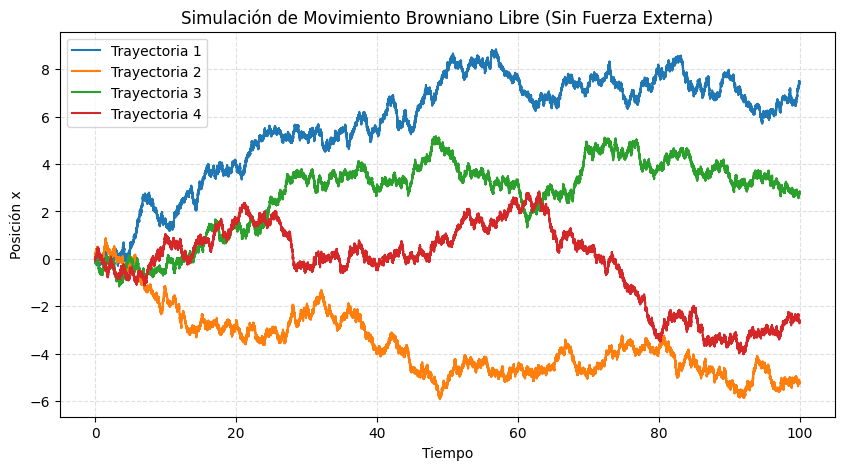

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración del generador de números aleatorios para reproducibilidad
rng = np.random.default_rng(50)

# Parámetros de la simulación
n_trayectorias = 4
n_pasos = 100000
dt = 0.001
tiempo = np.arange(n_pasos + 1) * dt

# Parámetros físicos
D = 0.1  # Coeficiente de difusión en gases

# Inicialización de posiciones (todas comienzan en x = 0)
x = np.zeros((n_trayectorias, n_pasos + 1))

# Simulación paso a paso (sin fuerzas externas: k = 0)
for t_idx in range(n_pasos):
    # Generamos ruidos gaussianos independientes para cada trayectoria (Z)
    Z = rng.normal(size=n_trayectorias)
    # Actualización de la posición
    x[:, t_idx + 1] = x[:, t_idx] + np.sqrt(2 * D * dt) * Z

# Graficar las trayectorias
plt.figure(figsize=(10, 5))
for i in range(n_trayectorias):
    plt.plot(tiempo, x[i], label=f'Trayectoria {i+1}')

plt.title('Simulación de Movimiento Browniano Libre (Sin Fuerza Externa)')
plt.xlabel('Tiempo')
plt.ylabel('Posición x')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

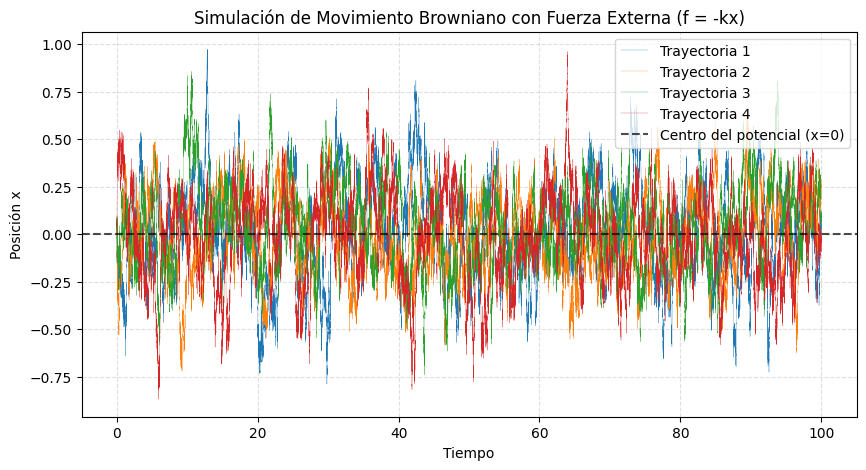

In [2]:
# @title Para que la simulación del movimeinto browniano sea comparable (libre con el de fuerza externa) debemos graficar el mismo dominio.

# Configuración para reproducibilidad
rng = np.random.default_rng(40)

# Parámetros de la simulación
n_trayectorias = 4
n_pasos = 100000
dt = 0.001
tiempo = np.arange(n_pasos + 1) * dt

# Parámetros físicos
D = 0.1        # Coeficiente de difusión
k = 4.0        # Constante del resorte (fuerza externa)
gamma = 2.0    # Coeficiente de fricción

# Inicialización de posiciones (todas comienzan en x = 0)
x_con_fuerza = np.zeros((n_trayectorias, n_pasos + 1))

# Simulación paso a paso usando la aproximación de Euler-Maruyama
for t_idx in range(n_pasos):
    Z = rng.normal(size=n_trayectorias)
    # Término determinista (deriva por fuerza del resorte) + término estocástico (difusión)
    deriva = -(k / gamma) * x_con_fuerza[:, t_idx] * dt
    difusion = np.sqrt(2 * D * dt) * Z
    x_con_fuerza[:, t_idx + 1] = x_con_fuerza[:, t_idx] + deriva + difusion

# Graficar las trayectorias bajo la influencia de la fuerza externa f = -kx
plt.figure(figsize=(10, 5))
for i in range(n_trayectorias):
    plt.plot(tiempo, x_con_fuerza[i], label=f'Trayectoria {i+1}', linewidth=0.2)

plt.axhline(0, color='black', linestyle='--', alpha=0.7, label='Centro del potencial (x=0)')
plt.title('Simulación de Movimiento Browniano con Fuerza Externa (f = -kx)')
plt.xlabel('Tiempo')
plt.ylabel('Posición x')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

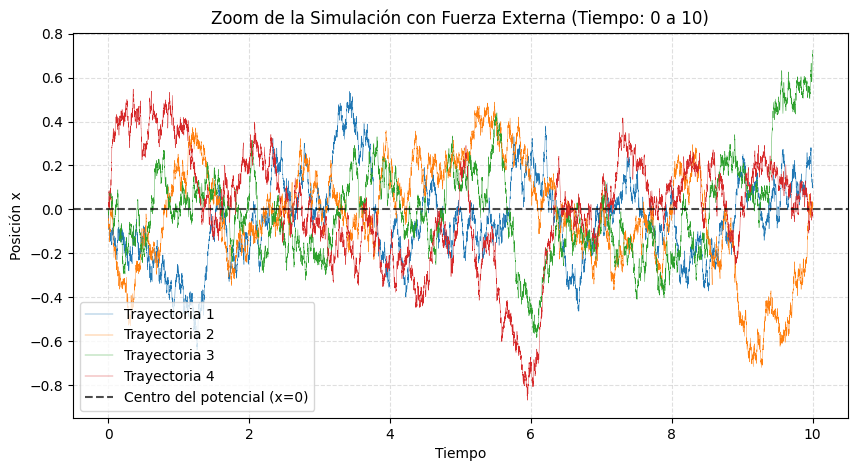

In [3]:
# @title Haciendo un pequeño zoom entre 0 y 10s
# Filtrar el tiempo y las posiciones para el intervalo [0, 10]
mascara_tiempo = tiempo <= 10.0
tiempo_zoom = tiempo[mascara_tiempo]
x_con_fuerza_zoom = x_con_fuerza[:, mascara_tiempo]

# Graficar el zoom
plt.figure(figsize=(10, 5))
for i in range(n_trayectorias):
    plt.plot(tiempo_zoom, x_con_fuerza_zoom[i], label=f'Trayectoria {i+1}', linewidth=0.3)

plt.axhline(0, color='black', linestyle='--', alpha=0.7, label='Centro del potencial (x=0)')
plt.title('Zoom de la Simulación con Fuerza Externa (Tiempo: 0 a 10)')
plt.xlabel('Tiempo')
plt.ylabel('Posición x')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

Los cambios en la posición son mayores cuando tenemos una fuerza externa actuando en el movimiento browniano. Se observa mayor movimiento aleatorio en los periodos de tiempo.

# Con modelos tipo Score

# Dinámica de Langevin con un campo score

Para una densidad de probabilidad $p_\theta(\mathbf{x})$,
definimos el campo score como

$$
\mathbf{s}_\theta(\mathbf{x})
=
\nabla_{\mathbf{x}}\log p_\theta(\mathbf{x}).
$$

Este campo apunta hacia la dirección de máximo crecimiento
local del logaritmo de la densidad.

## Relación entre el score y la fuerza

Para una distribución de Boltzmann,

$$
p_\theta(\mathbf{x})
=
\frac{1}{Z_\theta}
\exp\left[-\frac{U_\theta(\mathbf{x})}{k_BT}\right],
$$

el score es

$$
\mathbf{s}_\theta(\mathbf{x})
=
-\frac{1}{k_BT}\nabla_{\mathbf{x}}U_\theta(\mathbf{x}).
$$

Como la fuerza es $\mathbf{F}_\theta=-\nabla U_\theta$,

$$
\mathbf{F}_\theta(\mathbf{x})
=
k_BT\,\mathbf{s}_\theta(\mathbf{x}).
$$

## Ecuación estocástica

La dinámica sobreamortiguada es

$$
d\mathbf{X}_t
=
\frac{\mathbf{F}_\theta(\mathbf{X}_t)}{\gamma}\,dt
+
\sqrt{2D}\,d\mathbf{W}_t,
\qquad
D=\frac{k_BT}{\gamma}.
$$

Sustituyendo la fuerza por su expresión en términos del score:

$$
d\mathbf{X}_t
=
D\,\mathbf{s}_\theta(\mathbf{X}_t)\,dt
+
\sqrt{2D}\,d\mathbf{W}_t.
$$

El campo produce un desplazamiento dirigido y el ruido
mantiene las fluctuaciones. Durante esta evolución,
$\theta$ permanece fijo.

## Incrementos de Wiener

En $d$ dimensiones,

$$
\Delta\mathbf{W}_n
=
\sqrt{\Delta t}\,\boldsymbol{\epsilon}_n,
\qquad
\boldsymbol{\epsilon}_n\sim\mathcal{N}(\mathbf{0},I_d),
$$

con nuevos vectores independientes en cada paso.

## Actualización numérica

La aproximación de Euler–Maruyama es

$$
\mathbf{X}_{n+1}
=
\mathbf{X}_n
+
D\,\mathbf{s}_\theta(\mathbf{X}_n)\Delta t
+
\sqrt{2D\Delta t}\,\boldsymbol{\epsilon}_n.
$$

En unidades donde $D=1$:

$$
\mathbf{X}_{n+1}
=
\mathbf{X}_n
+
\mathbf{s}_\theta(\mathbf{X}_n)\Delta t
+
\sqrt{2\Delta t}\,\boldsymbol{\epsilon}_n.
$$

Con el score exacto y condiciones adecuadas de convergencia,
la dinámica continua reproduce $p_\theta$ a tiempos largos.
La actualización numérica introduce un error de discretización.

## Ejemplo: distribución gaussiana

Para una gaussiana con media $\boldsymbol{\mu}$ y
covarianza $vI_d$,

$$
\mathbf{s}(\mathbf{x})
=
-\frac{\mathbf{x}-\boldsymbol{\mu}}{v}.
$$



In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Gaussiana objetivo
mu = 0.0
varianza = 1.0

def densidad(x):
    return np.exp(-(x - mu)**2 / (2 * varianza)) / np.sqrt(
        2 * np.pi * varianza
    )

def score(x):
    return -(x - mu) / varianza



In [5]:
rng = np.random.default_rng(42)

n_trayectorias = 200
n_pasos = 1_000
dt = 0.01

# Todas las trayectorias comienzan en la misma posición
x = np.zeros((n_trayectorias, n_pasos))
np.shape(x)
t = np.arange(n_pasos+1 ) * dt

In [6]:
x = np.zeros((n_trayectorias, n_pasos + 1))

# Todas las trayectorias comienzan en cero
x[:, 0] = 0.0

for k in range(n_trayectorias):
    for j in range(n_pasos):
        ruido = rng.normal()

        x[k, j + 1] = (
            x[k, j]
            + dt * score(x[k, j])
            + np.sqrt(2 * dt) * ruido
        )

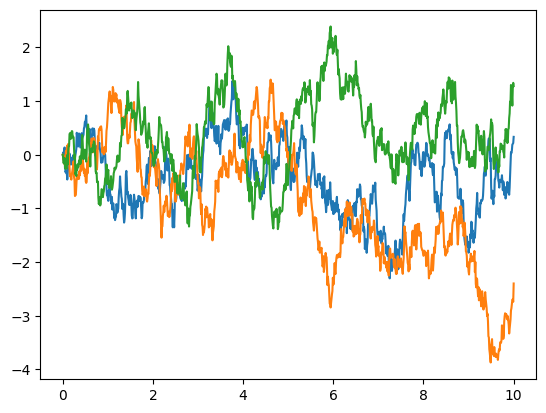

In [7]:
plt.plot(t, x[0])
plt.plot(t, x[1])
plt.plot(t, x[2])

In [8]:
x=np.concat(x)

Media de las muestras:    -0.0092
Varianza de las muestras: 0.9434
Varianza teórica discreta: 1.0050


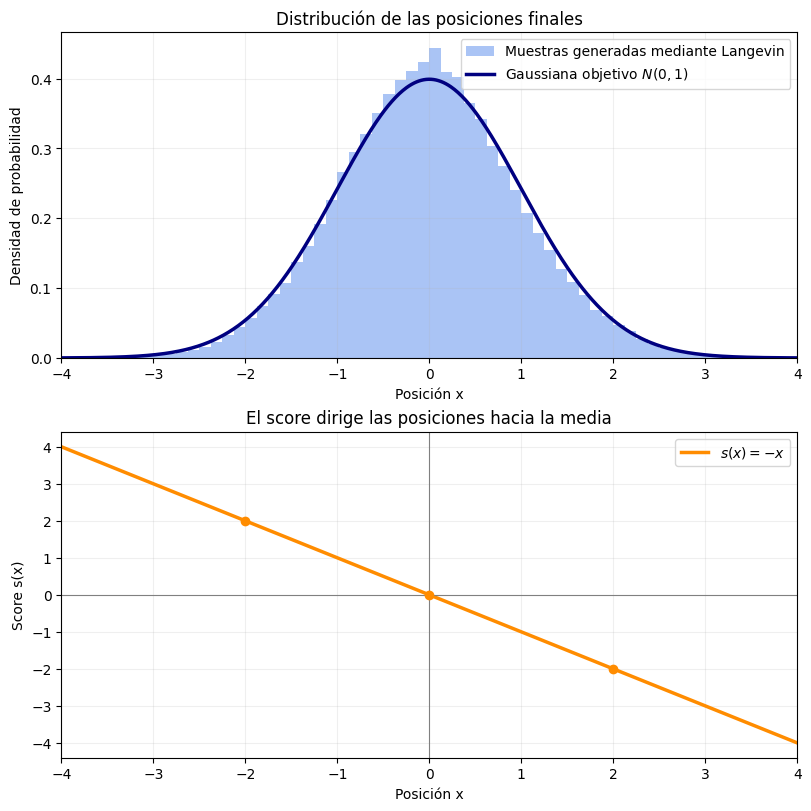

In [9]:
# Resultados
print(f"Media de las muestras:    {np.mean(x):.4f}")
print(f"Varianza de las muestras: {np.var(x):.4f}")

# Varianza estacionaria de la actualización discreta
varianza_discreta = varianza / (1 - dt / (2 * varianza))
print(f"Varianza teórica discreta: {varianza_discreta:.4f}")


# Gráficas
eje = np.linspace(-4, 4, 600)

fig, axes = plt.subplots(
    2, 1, figsize=(8, 8), constrained_layout=True
)

# Densidad objetivo e histograma de posiciones finales
axes[0].hist(
    x,
    bins=np.linspace(-4, 4, 65),
    density=True,
    color="cornflowerblue",
    alpha=0.55,
    label="Muestras generadas mediante Langevin"
)

axes[0].plot(
    eje,
    densidad(eje),
    color="navy",
    linewidth=2.5,
    label=r"Gaussiana objetivo ${N}(0,1)$"
)

axes[0].set(
    title="Distribución de las posiciones finales",
    xlabel="Posición x",
    ylabel="Densidad de probabilidad",
    xlim=(-4, 4)
)
axes[0].legend()
axes[0].grid(alpha=0.2)

# Campo score
axes[1].plot(
    eje,
    score(eje),
    color="darkorange",
    linewidth=2.5,
    label=r"$s(x) = -x$"
)

axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].axvline(mu, color="gray", linewidth=0.8)

axes[1].scatter(
    [-2, 0, 2],
    score(np.array([-2, 0, 2])),
    color="darkorange",
    zorder=3
)

axes[1].set(
    title="El score dirige las posiciones hacia la media",
    xlabel="Posición x",
    ylabel="Score s(x)",
    xlim=(-4, 4)
)
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.show()

Simule la dinámica de Langevin de partículas inicialmente distribuidas al azar en el plano, utilizando el campo score de una gaussiana de media \((0,0)\) y covarianza identidad. Visualice el campo y cinco trayectorias. Compare la distribución final de las partículas con la gaussiana objetivo y calcule su media y covarianza.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración de parámetros y reproducibilidad
rng = np.random.default_rng(42)
n_particulas = 1000
n_pasos = 1000
dt = 0.01
tiempo = np.arange(n_pasos + 1) * dt

# Posiciones iniciales distribuidas al azar uniformemente en [-4, 4] x [-4, 4]
X = rng.uniform(-4, 4, size=(n_particulas, 2, n_pasos + 1))

# 2. Definición del Score en 2D para una Gaussiana Estándar (media=0, cov=I)
def score_2d(pos):
    # s(x) = -x
    return -pos

# 3. Simulación de la Dinámica de Langevin (Euler-Maruyama)
for t_idx in range(n_pasos):
    # Ruido gaussiano bidimensional para cada partícula
    ruido = rng.normal(size=(n_particulas, 2))
    # s(X_n) en el paso actual
    s_actual = score_2d(X[:, :, t_idx])
    # Actualización de la posición
    X[:, :, t_idx + 1] = (
        X[:, :, t_idx]
        + s_actual * dt
        + np.sqrt(2 * dt) * ruido
    )

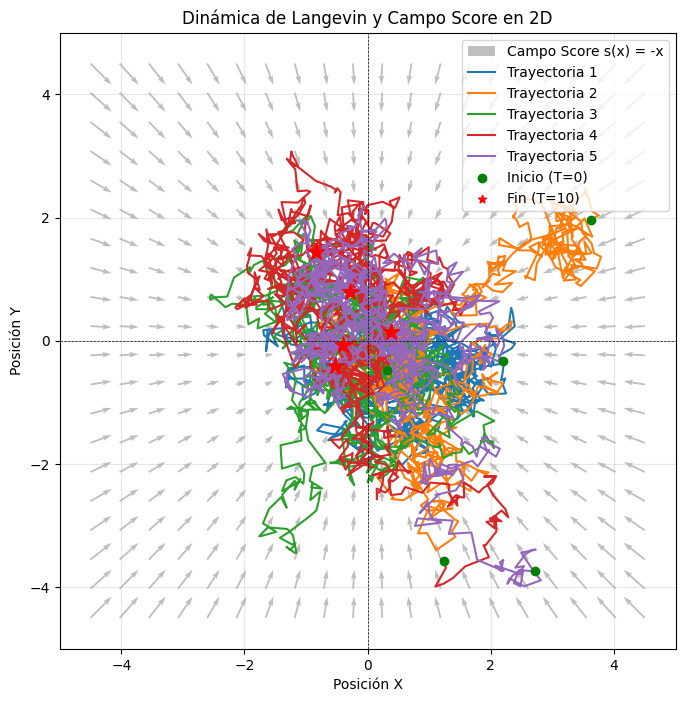

In [13]:
# 4. Visualización del campo score y 5 trayectorias individuales
plt.figure(figsize=(8, 8))

# Crear rejilla para graficar el campo score con vectores
x_grid, y_grid = np.meshgrid(np.linspace(-4.5, 4.5, 20), np.linspace(-4.5, 4.5, 20))
u_score = -x_grid
v_score = -y_grid
plt.quiver(x_grid, y_grid, u_score, v_score, color='gray', alpha=0.5, label='Campo Score s(x) = -x')

# Graficar la trayectoria de las primeras 5 partículas
for i in range(5):
    plt.plot(X[i, 0, :], X[i, 1, :], label=f'Trayectoria {i+1}', linewidth=1.5)
    # Marcar el punto de inicio con un círculo y el de fin con una estrella
    plt.scatter(X[i, 0, 0], X[i, 1, 0], color='green', marker='o', zorder=5)
    plt.scatter(X[i, 0, -1], X[i, 1, -1], color='red', marker='*', s=150, zorder=5)

# Decoración del gráfico
plt.scatter([], [], color='green', marker='o', label='Inicio (T=0)')
plt.scatter([], [], color='red', marker='*', label='Fin (T=10)')
plt.title('Dinámica de Langevin y Campo Score en 2D')
plt.xlabel('Posición X')
plt.ylabel('Posición Y')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.grid(alpha=0.3)
plt.legend(loc='upper right')
plt.gca().set_aspect('equal')
plt.show()

=== ESTADÍSTICAS FINALES DE LAS PARTÍCULAS ===
Media Empírica (esperada [0, 0]): [ 0.00387465 -0.0020174 ]
Covarianza Empírica (esperada Identidad):
[[ 0.98498511 -0.00865637]
 [-0.00865637  0.90678254]]



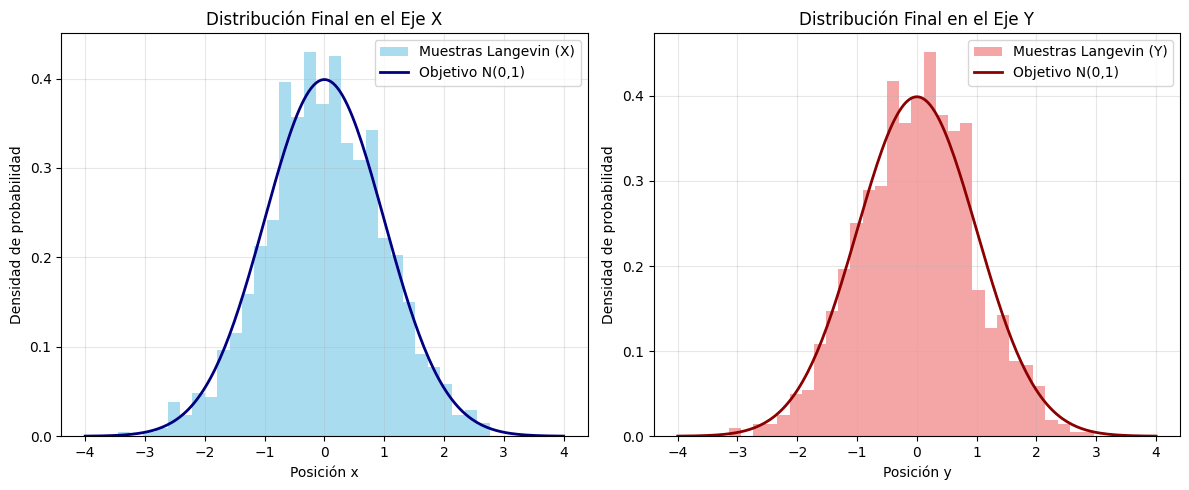

In [14]:
# 5. Comparación e Histograma de la distribución final frente a la Gaussiana objetivo
posiciones_finales = X[:, :, -1]

# Calcular estadísticas de las posiciones finales
media_final = np.mean(posiciones_finales, axis=0)
cov_final = np.cov(posiciones_finales.T)

print("=== ESTADÍSTICAS FINALES DE LAS PARTÍCULAS ===")
print(f"Media Empírica (esperada [0, 0]): {media_final}")
print(f"Covarianza Empírica (esperada Identidad):\n{cov_final}\n")

# Graficar la densidad de los puntos finales en comparación con la teórica en cada dimensión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
eje_teorico = np.linspace(-4, 4, 200)
densidad_teorica = np.exp(-eje_teorico**2 / 2) / np.sqrt(2 * np.pi)

# Dimensión X
axes[0].hist(posiciones_finales[:, 0], bins=30, density=True, color='skyblue', alpha=0.7, label='Muestras Langevin (X)')
axes[0].plot(eje_teorico, densidad_teorica, color='navy', linewidth=2, label='Objetivo N(0,1)')
axes[0].set_title('Distribución Final en el Eje X')
axes[0].set_xlabel('Posición x')
axes[0].set_ylabel('Densidad de probabilidad')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Dimensión Y
axes[1].hist(posiciones_finales[:, 1], bins=30, density=True, color='lightcoral', alpha=0.7, label='Muestras Langevin (Y)')
axes[1].plot(eje_teorico, densidad_teorica, color='darkred', linewidth=2, label='Objetivo N(0,1)')
axes[1].set_title('Distribución Final en el Eje Y')
axes[1].set_xlabel('Posición y')
axes[1].set_ylabel('Densidad de probabilidad')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()